     user_id  hour  activity   status
92         1    11         4   Normal
93        10    15         5   Normal
94         1    18        10   Normal
95         2     9         2   Normal
96         5    15         2   Normal
97         1    13         9   Normal
98         5    20         3   Normal
99         6    11         3   Normal
100        1     3        50  Anomaly
101        2     2        40  Anomaly


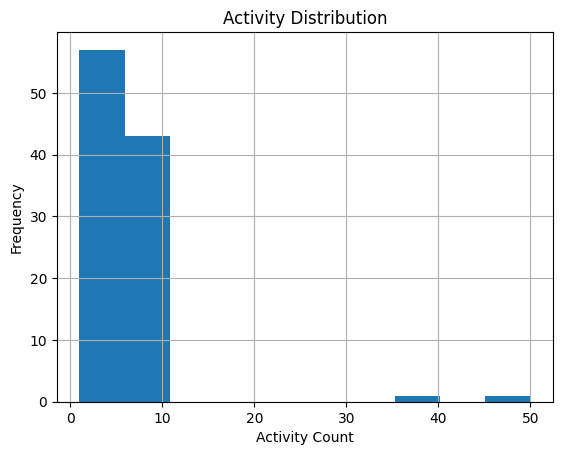

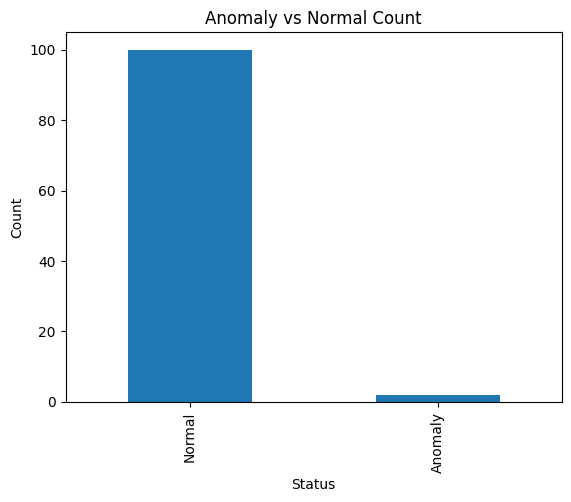

In [2]:
# Maan's User Activity Anomaly Detection System

import pandas as pd
import random
import matplotlib.pyplot as plt

# generate fake data
data = []

for i in range(100):
    user_id = random.randint(1, 10)
    hour = random.randint(8, 22)
    activity = random.randint(1, 10)
    data.append([user_id, hour, activity])

# add anomalies
data.append([1, 3, 50])
data.append([2, 2, 40])

df = pd.DataFrame(data, columns=["user_id", "hour", "activity"])

# calculate average
avg_activity = df["activity"].mean()

# anomaly detection
def detect_anomaly(row):
    if row["activity"] > avg_activity * 2 or row["hour"] < 6:
        return "Anomaly"
    return "Normal"

df["status"] = df.apply(detect_anomaly, axis=1)

# show last rows
print(df.tail(10))

# visualization: activity distribution
plt.figure()
df["activity"].hist()
plt.title("Activity Distribution")
plt.xlabel("Activity Count")
plt.ylabel("Frequency")
plt.show()

# visualization: anomalies vs normal
plt.figure()
df["status"].value_counts().plot(kind="bar")
plt.title("Anomaly vs Normal Count")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()